## The Anatomy of a Hit Song

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\github\python-data-science-handbook\Projects\data\dataset.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [4]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## Data Cleaning

In [6]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df = df.drop_duplicates()

In [9]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [11]:
df['duration_min'] = df['duration_ms']/60000
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550


##  Playing Detective

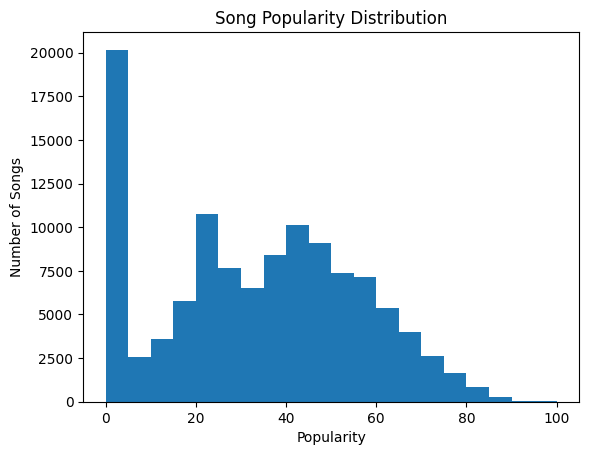

In [10]:
plt.hist(df['popularity'], bins=20)

plt.title("Song Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

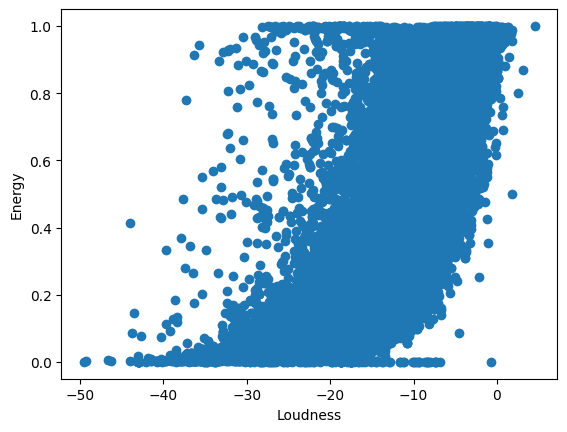

In [11]:
plt.scatter(df['loudness'], df['energy'])
plt.xlabel("Loudness")
plt.ylabel("Energy")

plt.show()

In [13]:
df["loudness"]

0         -6.746
1        -17.235
2         -9.734
3        -18.515
4         -9.681
           ...  
113995   -16.393
113996   -18.318
113997   -10.895
113998   -10.889
113999   -10.204
Name: loudness, Length: 113549, dtype: float64

In [18]:
high_dance = df[df['danceability'] > 0.8]
low_dance = df[df["danceability"] < 0.2]

In [19]:
high_dance

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
448,6339iq4yAm87arKgnNc922,Zee Avi,Acoustic Christmas Campfire,No Christmas For Me,0,160666,False,0.809,0.3130,9,...,1,0.0428,0.876000,0.000000,0.1120,0.350,114.955,4,acoustic,2.677767
616,7pxbZ29k1LJXvOdd2e5Bdn,Us The Duo,Shotgun,Shotgun,45,174884,False,0.806,0.2630,5,...,1,0.0502,0.787000,0.000000,0.1820,0.868,115.854,4,acoustic,2.914733
656,3zjr7jirhGwvqGuuJuIxjg,Andrew Foy;Renee Foy,Photograph,Photograph,30,218590,False,0.807,0.0459,4,...,1,0.0481,0.852000,0.000006,0.1020,0.275,110.512,4,acoustic,3.643167
663,12qmPGMrOCogibc7qyxT9s,Gen Hoshino,I Wanna Be Your Ghost (feat. Ghosts),I Wanna Be Your Ghost (feat. Ghosts),50,225533,False,0.829,0.7510,11,...,0,0.0645,0.014200,0.014000,0.0414,0.960,129.993,4,acoustic,3.758883
713,1z2fSrYZqrO5tMqzULn9OD,Tyrone Wells,"The ""Hits"" | Acoustic",Days I Will Remember,30,201506,False,0.804,0.4570,6,...,1,0.1970,0.600000,0.000000,0.1500,0.552,98.035,4,acoustic,3.358433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112869,3kVFYB1LkUYH4Q8cjpIJq6,Sagopa Kajmer,Romantizma,Leyli,37,197696,False,0.856,0.5960,8,...,0,0.2070,0.391000,0.000006,0.1040,0.578,94.973,4,turkish,3.294933
112909,3jxn92KU8l5RPjwLTGlMyg,Arem Ozguc;Arman Aydin;Jordan Rys,The One,The One,56,133375,False,0.863,0.6240,5,...,0,0.0437,0.000316,0.000131,0.0822,0.482,120.020,4,turkish,2.222917
112913,59YZrBAIg1tDH8squLd7gY,Cem Adrian,Salvatore,Salvatore,37,197513,False,0.811,0.5210,10,...,0,0.0374,0.246000,0.000010,0.1400,0.714,114.877,4,turkish,3.291883
113696,797ikuM3k4gkjaxStQnxgW,Cesária Evora;Ismaël Lô,Rogamar,Africa Nossa (with Ismaël Lô),25,232146,False,0.804,0.8540,7,...,1,0.0487,0.611000,0.000083,0.3950,0.841,104.004,4,world-music,3.869100


In [20]:
low_dance

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
2032,4nzIpIeHWiuFQnOV5ZELnj,Deftones,Metal Lives!,Ohms,0,250222,False,0.1120,0.9780,4,...,1,0.1170,0.000108,0.0241,0.1170,0.3710,173.097,3,alt-rock,4.170367
2033,0FrFqoPT7JB0ezIU9g2OLC,Deftones,Metal,Ohms,0,250222,False,0.1120,0.9780,4,...,1,0.1170,0.000108,0.0241,0.1170,0.3710,173.097,3,alt-rock,4.170367
2079,2Nmgl5ms85CE90Yu4lm8jL,Weezer,Alternative Christmas 2022,O Holy Night,0,244306,False,0.1730,0.6090,3,...,1,0.0482,0.359000,0.0000,0.1000,0.0988,197.819,3,alt-rock,4.071767
2082,0PSKFp3zoNmJzDsOHeLV6l,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.1650,0.4340,0,...,1,0.0288,0.316000,0.1710,0.2130,0.1860,77.983,3,alt-rock,3.278717
2085,4fdy3vg2bCXU6L77vC6li8,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.1650,0.4340,0,...,1,0.0288,0.316000,0.1710,0.2130,0.1860,77.983,3,alt-rock,3.278717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113972,6xZuzUxNn5AGIPQ2FvXXLP,Mc_team,Frecuencias Curativas Solfeggio 528 Hz,528Hz La frecuencia del amor,21,170387,False,0.1700,0.0520,2,...,1,0.0374,0.875000,0.9040,0.1290,0.0475,114.573,4,world-music,2.839783
113977,3FuOBnk7Xsglp7AIsHQVaA,Reiki Armonía,Música Relajante para Reiki - Canciones de Fon...,Paz Mental,21,290999,False,0.0672,0.0903,9,...,1,0.0401,0.970000,0.9770,0.0930,0.0361,76.042,4,world-music,4.849983
113986,2ZYEpnio0Z6EfJWy2JAf53,Dulces Sueños,#20 Sueños Vividos - Música Intrumental Suave ...,Sueños Vividos,21,335999,False,0.1980,0.2570,8,...,1,0.0415,0.968000,0.9490,0.1100,0.0381,89.494,4,world-music,5.599983
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.1720,0.2350,5,...,1,0.0422,0.640000,0.9280,0.0863,0.0339,125.995,5,world-music,6.416650


In [17]:
high_dance['tempo'].mean()

np.float64(115.53546823852582)

In [21]:
low_dance["tempo"].mean()

np.float64(104.72672037484884)

## The Grand Finale

In [22]:
df[['popularity', 'danceability', 'energy', 'loudness', 'tempo']].corr()

,popularity,danceability,energy,loudness,tempo
popularity,1.000000,0.034407,-0.002447,0.047368,0.012187
danceability,0.034407,1.000000,0.131694,0.256559,-0.051517
energy,-0.002447,0.131694,1.000000,0.760624,0.247361
loudness,0.047368,0.256559,0.760624,1.000000,0.212181
tempo,0.012187,-0.051517,0.247361,0.212181,1.000000
